# Praktische Übung 5
Das Ziel dieser Programmieraufgabe ist die Entwicklung eines lernbasierten Algorithmus zur Registrierung von 2D-Gehirn-MRT-Schichtbildern. Das Notebook stellt Ihnen einen fertig vorverarbeiteten und in Trainings- und Testdaten unterteilten Datensatz zur Verfügung. Für jedes Bild sind 25 anatomische Regionen segmentiert worden.

In [1]:
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import tqdm

from tqdm.notebook import trange
from torchinfo import summary

!pip install wget
import wget


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
dataset_url = 'https://surfer.nmr.mgh.harvard.edu/ftp/data/neurite/data/neurite-oasis.2d.v1.0.tar'

def get_data(data_url):
    filename = './neurite-oasis.2d.v1.0.tar'
    if not os.path.exists(filename):
        wget.download(data_url)
        !mkdir "neurite-oasis2d/"
        !tar -xvf "neurite-oasis.2d.v1.0.tar" -C "neurite-oasis2d/"

get_data(dataset_url)

img_oasis = []
seg_oasis = []
for i in trange(500):
    file = 'neurite-oasis2d/OASIS_OAS1_0'+str(i).zfill(3)+'_MR1/slice_norm.nii.gz'
    file_seg = 'neurite-oasis2d/OASIS_OAS1_0'+str(i).zfill(3)+'_MR1/slice_seg24.nii.gz'
    if(os.path.exists(file)):
        img_oasis.append(torch.from_numpy(nib.load(file).get_fdata()).float().squeeze().t())
        seg_oasis.append(torch.from_numpy(nib.load(file_seg).get_fdata()).float().squeeze().t())

img_oasis = torch.stack(img_oasis).unsqueeze(1).cuda()
seg_oasis = torch.stack(seg_oasis).unsqueeze(1).cuda()

train_imgs = img_oasis[:350, ...]
train_segs = seg_oasis[:350, ...]
test_imgs = img_oasis[350:, ...]
test_segs = seg_oasis[350:, ...]

print(test_imgs.min(), test_imgs.max())
print(test_segs.min(), test_segs.max())
print(test_imgs.shape)

  0%|          | 0/500 [00:00<?, ?it/s]

tensor(0., device='cuda:0') tensor(0.9529, device='cuda:0')
tensor(0., device='cuda:0') tensor(24., device='cuda:0')
torch.Size([64, 1, 192, 160])


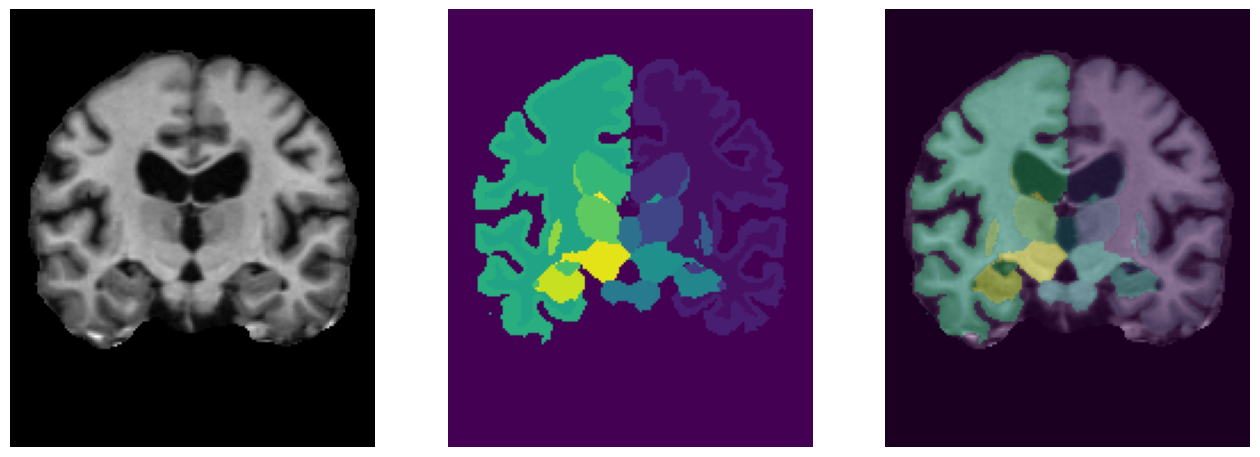

In [3]:
# Plot eines Beispieltrainingsbildes
fig, ax = plt.subplots(1, 3, figsize=(16, 6))
ax[0].imshow(train_imgs[0, 0].cpu(), 'gray')
ax[1].imshow(train_segs[0, 0].cpu())
ax[2].imshow(train_imgs[0, 0].cpu(), 'gray')
ax[2].imshow(train_segs[0, 0].cpu(), alpha=0.4)
[axi.set_axis_off() for axi in ax.ravel()]
plt.show()

In [4]:
vectors = [torch.arange(0, s)/(s - 1) for s in (192, 160)]
grids = torch.meshgrid(vectors)
grid = torch.stack(grids)
grid = torch.unsqueeze(grid, 0)
id_grid = (2 * (grid.type(torch.FloatTensor).cuda() - 0.5))[:, [1, 0], :, :]

# Evaluationsfunktion: Bewertet die Registrierungsergebnisse anhand von drei
# Metriken:
# 1. Bildähnlichkeit nach der Deformation (MSE)
# 2. Durchschnittlicher Dice-Score der anatomischen Strukturen nach der Deform.
# 3. Regularität/Plausibilität des Deformationsfeldes, bemessen durch
#    Prozentsatz von Invertierungen im Feld (Pixel mit negativer Jacobi-Det.)
def eval_reg_result(fix_img, mov_img, fix_seg, mov_seg, def_field, disp_only=True):
    if disp_only:
        def_grid = id_grid + def_field
        def_grid = def_grid.permute(0, 2, 3, 1)
    else:
        def_grid = def_field.permute(0, 2, 3, 1)
    warped = F.grid_sample(mov_img, def_grid, align_corners=False)
    warped_seg = F.grid_sample(mov_seg, def_grid, align_corners=False, mode='nearest')

    img_sim = torch.mean((fix_img - warped)**2)
    dice = dice_coeff(warped_seg, fix_seg, 25).mean()

    jac_det = jacobian_determinant_2d(def_field, 2/160, 2/192)
    neg_jac = torch.sum((jac_det < 0)) / (188 * 156)
    return img_sim.item(), dice.item(), neg_jac.item()


def dice_coeff(outputs, labels, max_label):
    dice = torch.FloatTensor(max_label - 1).fill_(0)
    for label_num in range(1, max_label):
        iflat = (outputs==label_num).view(-1).float()
        tflat = (labels==label_num).view(-1).float()
        intersection = torch.mean(iflat * tflat)
        dice[label_num - 1] = (2. * intersection) / (1e-8 + torch.mean(iflat) + torch.mean(tflat))
    return dice


def jacobian_determinant_2d(def_field, spacing_x, spacing_y):
    grady = nn.Conv2d(2, 2, (3, 1), padding=(1, 0), bias=False, groups=2)
    grady.weight.data[:, 0, :, 0] = torch.tensor([1/spacing_y, 0, -1/spacing_y]).view(1, 3).repeat(2, 1)
    grady.to(def_field.device)

    gradx = nn.Conv2d(2, 2, (1, 3), padding=(0, 1), bias=False, groups=2)
    gradx.weight.data[:, 0, 0, :] = torch.tensor([1/spacing_x, 0, -1/spacing_x]).view(1, 3).repeat(2, 1)
    gradx.to(def_field.device)

    with torch.no_grad():
        jacobian = torch.cat((grady(def_field), gradx(def_field)), 0) + torch.eye(2, 2).view(2, 2, 1, 1).to(def_field.device)
        jacobian = jacobian[:, :, 2:-2, 2:-2]
        jac_det = jacobian[0, 0, :, :] * jacobian[1, 1, :, :] - jacobian[1, 0, :, :] * jacobian[0, 1, :, :]

    return jac_det


/home/nicolas/miniconda3/envs/uni/lib/python3.14/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /home/task_177486203601641/croot/libtorch_1774862083551/work/aten/src/ATen/native/TensorShape.cpp:4317.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [5]:
# Evaluation über alle Testbilder
mses_test = []
dices_test = []
neg_jac_test = []

for i in range(len(test_imgs[:10])):
    for j in range(len(test_imgs[:10])):
        if i == j:
            continue

        fix_img = img_oasis[i, ...].unsqueeze(0)
        fix_seg = seg_oasis[i, ...].unsqueeze(0)
        mov_img = img_oasis[j, ...].unsqueeze(0)
        mov_seg = seg_oasis[j, ...].unsqueeze(0)

        # Todo: Replace empty deformation field
        def_field = torch.zeros((1, 2, 192, 160)).cuda()
        def_field[:, :, 0::10, :] = 0.1
        def_field[:, :, 2::10, :] = -0.1

        m, d, n = eval_reg_result(fix_img, mov_img, fix_seg, mov_seg, def_field)
        mses_test.append(m)
        dices_test.append(d)
        neg_jac_test.append(n)

print('Average MSE: {:.6f}'.format(np.array(mses_test).mean()))
print('Average Dice: {:.6f}'.format(np.array(dices_test).mean()))
print('Average amount of inversions: {:.6f}'.format(np.array(neg_jac_test).mean()))

Average MSE: 0.009087
Average Dice: 0.432380
Average amount of inversions: 0.202128


In [6]:
# Todo: Entwickeln Sie einen lernbasierten Ansatz zur Registrierung der
# 2D-Gehirn-MRT-Schichten

Todo: Entwickeln Sie einen lernbasierten Ansatz zur Registrierung der 2D-Gehirn-MRT-Schichten

* Nutzen Sie eine unüberwachte (!) Loss-Funktion zum Training
* Die Wahl der Netzwerkarchitektur und anderer Komponenten bzw. Hyperparameter Ihres Algorithmus steht Ihnen frei
* Nutzen Sie zum Testen Ihres Algorithmus die oben gegebene Routine
* Stellen Sie Ihren Algorithmus und Ihre Ergebnisse in einer kurzen Präsentation zusammen

--> **Vorstellung in der Übung am 13.7. (3-5 Minuten pro Person)**

--> **Teilnahmepflicht!**

### make datasets

In [7]:
class VoxelDataSet(torch.utils.data.Dataset):
    def __init__(self,imgs, seg):
        self.imgs = imgs
        self.seg = seg
    
    def __len__(self):
        return self.imgs.shape[0]
    
    def __getitem__(self, idx):
        fix_img = self.imgs[idx]
        fix_seg = self.seg[idx]
        mov_img = self.imgs[idx +1 if idx > self.imgs.shape[0] else idx -1]
        mov_seg = self.seg[idx +1 if idx > self.imgs.shape[0] else idx -1]
        return fix_img, mov_img, fix_seg, mov_seg
    

train_set = VoxelDataSet(train_imgs,train_segs)
train_loader = torch.utils.data.DataLoader(train_set,1,shuffle=True)

test_set = VoxelDataSet(test_imgs,test_segs)
test_loader = torch.utils.data.DataLoader(test_set,1,shuffle=False)

### Modell
start with unet layer. Model taken and adopted from exercise 2

In [8]:
# To do
class VoxelMorph(nn.Module):
    def __init__(self, input_channels):
        super().__init__()

        # encoder 
        self.encoder1 = nn.Sequential(
                        nn.Conv2d(input_channels,20,3,1,1,bias=False),
                        nn.InstanceNorm2d(20),
                        nn.ReLU(),
                        nn.Conv2d(20,20,3,1,1,bias=False),
                        nn.InstanceNorm2d(20),
                        nn.ReLU(),
                        nn.MaxPool2d(2,2)
                        )
        self.encoder2 = nn.Sequential(
                        nn.Conv2d(20,40,3,1,1,bias=False),
                        nn.InstanceNorm2d(40),
                        nn.ReLU(),
                        nn.Conv2d(40,40,3,1,1,bias=False),
                        nn.InstanceNorm2d(40),
                        nn.ReLU(),
                        nn.MaxPool2d(2,2)
                        )
        self.encoder3 = nn.Sequential(
                        nn.Conv2d(40,80,3,1,1,bias=False),
                        nn.InstanceNorm2d(80),
                        nn.ReLU(),
                        nn.Conv2d(80,80,3,1,1,bias=False),
                        nn.InstanceNorm2d(80),
                        nn.ReLU(),
                        nn.MaxPool2d(2,2)
                        )

        # Bottleneck
        self.bottle_neck = nn.Sequential(
                        nn.Conv2d(80,120,3,1,1,bias=False),
                        nn.InstanceNorm2d(120),
                        nn.ReLU(),
                        nn.Conv2d(120,120,3,1,1,bias=False),
                        nn.InstanceNorm2d(120),
                        nn.ReLU()
                        )

        # Decoder
        self.decoder3 = nn.Sequential(
                        nn.Conv2d(80+120,120,3,1,1,bias=False),
                        nn.InstanceNorm2d(120),
                        nn.ReLU(),
                        nn.Conv2d(120,80,3,1,1,bias=False),
                        nn.InstanceNorm2d(80),
                        nn.ReLU()
                        )
        self.decoder2 = nn.Sequential(
                        nn.Conv2d(40+80,80,3,1,1,bias=False),
                        nn.InstanceNorm2d(80),
                        nn.ReLU(),
                        nn.Conv2d(80,60,3,1,1,bias=False),
                        nn.InstanceNorm2d(60),
                        nn.ReLU()
                        )
        self.decoder1 = nn.Sequential(
                        nn.Conv2d(60+20,60,3,1,1,bias=False),
                        nn.InstanceNorm2d(60),
                        nn.ReLU(),
                        nn.Conv2d(60,40,3,1,1,bias=False),
                        nn.InstanceNorm2d(40),
                        nn.ReLU(),
                        )
        
        self.clf = nn.Sequential(
                        nn.Conv2d(40,20,3,1,1),
                        nn.Conv2d(20,20,3,1,1),
                        nn.Conv2d(20,2,1,1,1)
                        )

        # Maxpooling und Upsampling (bilinear interpolation)
        # ...

    def forward(self, fix_img,mov_img):
        inputs = torch.concat([fix_img,mov_img],dim=1)
        B, C, H, W = inputs.shape
        # Encoder
        enc1 = self.encoder1(inputs)
        enc2 = self.encoder2(enc1)
        enc3 = self.encoder3(enc2)
        #bottleneck
        bottleneck = self.bottle_neck(enc3)
        #decoder 
        in_dec3 = F.interpolate(bottleneck,size=enc3.shape[2:],mode="bilinear",align_corners=False)
        dec3 = self.decoder3(torch.concat([enc3,in_dec3],dim=1))

        in_dec2 = F.interpolate(dec3,size=enc2.shape[2:],mode="bilinear",align_corners=False)
        dec2 = self.decoder2(torch.concat([enc2,in_dec2],dim=1))

        in_dec1 = F.interpolate(dec2,size=enc1.shape[2:],mode="bilinear",align_corners=False)
        dec1 = self.decoder1(torch.concat([enc1,in_dec1],dim=1))

        output = self.clf(dec1)
        output = F.interpolate(output, size=(H, W), mode="bilinear")

        return output

    def weight_init(self, mean, std):
        for m in self._modules:
            normal_init(self._modules[m], mean, std)

def normal_init(m, mean, std):
    if isinstance(m, nn.ConvTranspose2d) or isinstance(m, nn.Conv2d):
        m.weight.data.normal_(mean, std)
        m.bias.data.zero_()


In [9]:
#sanity check to check the shapes
net = VoxelMorph(2).cuda()
ex_img, mov_img, ex_seg, mov_seg = next(iter(train_loader))
#show model
print(summary(net))

print(f"img shape: {ex_img.shape}, seg shape: {ex_seg.shape}")
x = net(ex_img,mov_img)
print(x.shape,f"len dataset: {len(train_loader)}")
del net

Layer (type:depth-idx)                   Param #
VoxelMorph                               --
├─Sequential: 1-1                        --
│    └─Conv2d: 2-1                       360
│    └─InstanceNorm2d: 2-2               --
│    └─ReLU: 2-3                         --
│    └─Conv2d: 2-4                       3,600
│    └─InstanceNorm2d: 2-5               --
│    └─ReLU: 2-6                         --
│    └─MaxPool2d: 2-7                    --
├─Sequential: 1-2                        --
│    └─Conv2d: 2-8                       7,200
│    └─InstanceNorm2d: 2-9               --
│    └─ReLU: 2-10                        --
│    └─Conv2d: 2-11                      14,400
│    └─InstanceNorm2d: 2-12              --
│    └─ReLU: 2-13                        --
│    └─MaxPool2d: 2-14                   --
├─Sequential: 1-3                        --
│    └─Conv2d: 2-15                      28,800
│    └─InstanceNorm2d: 2-16              --
│    └─ReLU: 2-17                        --
│    └─Conv2

In [10]:
def diffusion_regularization(flow):
    #thanks to chatty
    # Unterschiede in x-Richtung
    dx = flow[:, :, :, 1:] - flow[:, :, :, :-1]
    # Unterschiede in y-Richtung
    dy = flow[:, :, 1:, :] - flow[:, :, :-1, :]
    # quadratische Diffusionsenergie
    loss = torch.mean(dx ** 2) + torch.mean(dy ** 2)

    return loss

### Training


LR=0.001, lambda=0.01


/home/nicolas/miniconda3/envs/uni/lib/python3.14/site-packages/torch/nn/functional.py:5100: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(
/home/nicolas/miniconda3/envs/uni/lib/python3.14/site-packages/torch/optim/lr_scheduler.py:192: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Epoch 0/100 | train loss: 0.00733 | val loss: 0.00560 | val dice: 0.67250 | val jacob: 0.46242 | 
Epoch 5/100 | train loss: 0.00390 | val loss: 0.00697 | val dice: 0.65692 | val jacob: 0.57607 | 
Early stopping in epoch 10

LR=0.001, lambda=0.1
Epoch 0/100 | train loss: 0.01678 | val loss: 0.06970 | val dice: 0.13078 | val jacob: 0.58517 | 
Epoch 5/100 | train loss: 0.00938 | val loss: 0.06610 | val dice: 0.18190 | val jacob: 0.65535 | 
Epoch 10/100 | train loss: 0.00884 | val loss: 0.06501 | val dice: 0.17472 | val jacob: 0.65818 | 
Epoch 15/100 | train loss: 0.00841 | val loss: 0.06716 | val dice: 0.16031 | val jacob: 0.65582 | 
Early stopping in epoch 18

LR=0.001, lambda=0.5
Epoch 0/100 | train loss: 0.04056 | val loss: 0.31953 | val dice: 0.09200 | val jacob: 0.66844 | 
Epoch 5/100 | train loss: 0.02911 | val loss: 0.32024 | val dice: 0.15102 | val jacob: 0.71976 | 
Epoch 10/100 | train loss: 0.02852 | val loss: 0.31311 | val dice: 0.17144 | val jacob: 0.71035 | 
Epoch 15/100 | tr

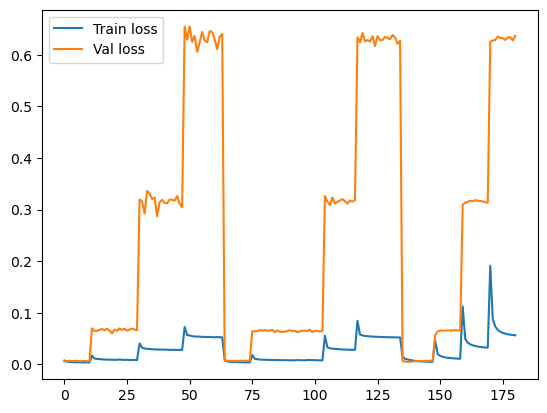

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
epochs = 100
net = VoxelMorph(2).to(device)
optim = torch.optim.Adam(net.parameters(),lr=1e-4)
lr_scheduler = torch.optim.lr_scheduler.ExponentialLR(optim,0.995)
lambda_reg = 0.5
best_val_loss = float("inf")
patience = 10
epochs_without_improvement = 0
train_losses = []
val_losses = []
lrs = [1e-3, 1e-4,1e-5]
lambda_regs = [0.01,0.1, 0.5, 1.0]

best_overall_loss = float("inf")
best_config = None


vectors = [torch.arange(0, s)/(s - 1) for s in (192, 160)]
grids = torch.meshgrid(vectors)
grid = torch.stack(grids)
grid = torch.unsqueeze(grid, 0)
id_grid = (2 * (grid.type(torch.FloatTensor).cuda() - 0.5))[:, [1, 0], :, :]

for lr in lrs:
    for lambda_reg in lambda_regs:

        print(f"\nLR={lr}, lambda={lambda_reg}")

        net = VoxelMorph(2).to(device)
        optim = torch.optim.Adam(net.parameters(), lr=lr)

        best_val_loss = float("inf")
        epochs_without_improvement = 0
        for epoch in range(epochs):
            running_loss = 0.0
            net.train()

            for fix_img, mov_img, fix_seg, mov_seg in train_loader:
                optim.zero_grad()
                fix_img, mov_img, fix_seg, mov_seg = fix_img.to(device), mov_img.to(device), fix_seg.to(device), mov_seg.to(device)
                #wrap image to moving img
                reg_field = net(fix_img,mov_img)
                reg_field = (reg_field + id_grid).permute(0,2,3,1)
                #compute l smooth diffusion regularisation
                l_diff = diffusion_regularization(reg_field)
                #validation for training
                # metrics = eval_reg_result(fix_img,mov_img,fix_seg,mov_seg,def_field=reg_field.permute(0,3,1,2))

                # l_sim, train_dice, jacob_deter = metrics
                warped = F.grid_sample(mov_img,reg_field)
                l_sim = F.mse_loss(fix_img, warped)
                #combine all thre losses
                loss = l_sim + lambda_reg*l_diff
                loss.backward()
                optim.step()
                running_loss += loss.item()
            lr_scheduler.step()
            epoch_train_loss = running_loss / len(train_loader)
            train_losses.append(epoch_train_loss)
                
            net.eval()
            
            running_val_loss = 0.0
            for fix_img, mov_img, fix_seg, mov_seg in test_loader:
                fix_img, mov_img, fix_seg, mov_seg = fix_img.to(device), mov_img.to(device), fix_seg.to(device), mov_seg.to(device)
                with torch.no_grad():
                #wrap image to moving img
                    reg_field = net(fix_img,mov_img)
                    reg_field = reg_field.permute(0,2,3,1)
                    #compute l smooth diffusion regularisation
                    l_diff = diffusion_regularization(reg_field)
                    #validation for training
                    metrics = eval_reg_result(fix_img,mov_img,fix_seg,mov_seg,def_field=reg_field.permute(0,3,1,2))
                    sim, dice, jacob_deter = metrics
                #combine all thre losses
                val_loss = sim + lambda_reg * l_diff
                running_val_loss += val_loss.item()
            epoch_val_loss = running_val_loss / len(test_loader)
            val_losses.append(epoch_val_loss)
            # best model
            # if epoch_val_loss < best_val_loss:
            #     best_val_loss = epoch_val_loss
            #     epochs_without_improvement = 0
            # else:
            #     epochs_without_improvement += 1
            # Early Stopping
            if epochs_without_improvement >= patience:
                print(f"Early stopping in epoch {epoch}")
                break
            if epoch % 5 == 0:
                print(
                f"Epoch {epoch}/{epochs} | "
                f"train loss: {epoch_train_loss:.5f} | "
                f"val loss: {epoch_val_loss:.5f} | "
                f"val dice: {dice:.5f} | "
                f"val jacob: {jacob_deter:.5f} | "
            )

    

# best_net = VoxelMorph(2).to(device)
# best_net.load_state_dict(torch.load("best_model_overall.pt",weights_only=True))
# plt.plot(np.arange(len(train_losses)),train_losses,label="Train loss")
# plt.plot(np.arange(len(train_losses)),val_losses,label="Val loss")
# plt.legend()
# plt.show()